# Exercise 7

## Your task:

Make the graph! You need to implement an **Automatic Higher or Lower Game**.

Set the bounds to between **1 to 20**. The Graph has to keep guessing (**max number of guesses is 9**) where if the guess is correct, then it stops, but if not we keep looping until we hit the max limit of 9.

Each time a number is guessed, the **hint node should say higher or lower** and the graph should account for this information and guess the next guess accordingly.

**Input:** `{"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20}`

**Hint:** It will need to adjust its bounds after every guess based on the hint provided by the hint node.

---

## Graph Visualisation (ASCII)

```text
       [ __start__ ]
             |
             v
         [ setup ]
             |
             v
         [ guess ] <----------+
             |                |
             v                |
        [ hint node ]         |
             |                |
    _________|_________       |
   |                   |      |
[ Correct ]      [ Incorrect ]|
   |             (continue)---|
   v                   |
[ Stop ]         [ Max Attempts? ]
                       |
                       v
                    [ Stop ]

In [333]:
# Imports
import random
import traceback
from typing import TypedDict, List, Literal
from langgraph.graph import StateGraph, START, END
from tools.VGraph import Helper


In [334]:
# Tools
__tools__ = Helper()

In [335]:
# Schema
class Agent7(TypedDict):
    player_name: str
    guess: List[int]
    attempt: int
    lower_bound: int
    upper_bound: int
    target_number: int # The number AI is looking for
    hint: Literal["Higher", "Lower", "Correct"]

In [336]:
# Nodes
def setup_node(state: Agent7) -> Agent7:
    try:

        return {
            "guess": [],
            "attempt": 0,
            "lower_bound": 1,
            "upper_bound": 20
        }
    except Exception as e:
        traceback.print_exc()

def guess_node(state: Agent7) -> Agent7:
    try:
        current_guess = random.randint(state["lower_bound"], state["upper_bound"])
        state["current_number"] = current_guess
        state["guess"].append(current_guess)
        state["attempt"] += 1
        return state
    except Exception as e:
        traceback.print_exc()

def hint_node(state: Agent7) -> Agent7:
    try:
        last_guess = state["guess"][-1]
        target = state["target_number"]

        if last_guess > target:
            state["hint"] = "Lower"
        elif last_guess < target:
            state["hint"] = "Higher"
        else:
            state["hint"] = "Correct"

        return state
    except Exception as e:
        traceback.print_exc()

def router(state: Agent7) -> str:
    try:
        if state["hint"] == "Correct" or state["attempt"] >= 9:
            return "exit"
        return "loop"
    except Exception as e:
        traceback.print_exc()

In [337]:
# Graph
graph = StateGraph(Agent7)

graph.add_node("setup", setup_node)
graph.add_node("guess", guess_node)
graph.add_node("hint", hint_node)

graph.add_edge(START, "setup")
graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint")

graph.add_conditional_edges(
    source="hint",
    path=router,
    path_map={
        "exit": END,
        "loop": "guess"
    }
)

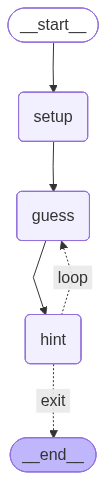

In [338]:
# Create and view App
app = graph.compile()
__tools__.view_graph(app)

In [343]:
# Checker
res = app.invoke(
    {
        "player_name": "Student",
        "target_number": 19, # Secret number
        "guesses": [],
        "attempts": 0,
        "lower_bound": 1,
        "upper_bound": 20,
        "hint": None
    }
)

__tools__.monitor({"RESULT": res})

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
{
    "RESULT": {
        "player_name": "Student",
        "guess": [
            5,
            15,
            17,
            19
        ],
        "attempt": 4,
        "lower_bound": 1,
        "upper_bound": 20,
        "target_number": 19,
        "hint": "Correct"
    }
}
####################################################################################################
